# 第7章: 機械学習

本章では、[Stanford Sentiment Treebank (SST)](https://nlp.stanford.edu/sentiment/) データセットを用い、評判分析器（ポジネガ分類器）を構築する。ここでは処理を簡略化するため、[General Language Understanding Evaluation (GLUE)](https://gluebenchmark.com/) ベンチマークで配布されているSSTデータセットを用いる。


## 60. データの入手・整形

GLUEのウェブサイトから[SST-2](https://dl.fbaipublicfiles.com/glue/data/SST-2.zip)データセットを取得せよ。学習データ（`train.tsv`）と検証データ（`dev.tsv`）のぞれぞれについて、ポジティブ (1) とネガティブ (0) の事例数をカウントせよ。

In [51]:
import os
import csv
import urllib.request
import zipfile
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import matplotlib.pyplot as plt

In [3]:
# 1. データセットのダウンロードURLと保存先の設定
url = "https://dl.fbaipublicfiles.com/glue/data/SST-2.zip"
zip_path = "SST-2.zip"

# ダウンロードと展開処理
print("SST-2データセットをダウンロード")
urllib.request.urlretrieve(url, zip_path)

print("ZIPファイルを展開")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

SST-2データセットをダウンロード
ZIPファイルを展開


In [5]:
train_path = "SST-2/train.tsv"
dev_path = "SST-2/dev.tsv"

# 3. pandasを使用してTSVファイルを読み込み（タブ区切り）
# ヘッダー（'sentence', 'label'）
train_df = pd.read_csv(train_path, sep='\t')
dev_df = pd.read_csv(dev_path, sep='\t')

# 4. ラベル（ポジティブ: 1, ネガティブ: 0）のカウント
# 学習データ
train_counts = train_df['label'].value_counts()
train_posi = train_counts.get(1)
train_nega = train_counts.get(0)

print("【学習データの事例数】")
print(f"ポジティブ (1): {train_posi:,}")
print(f"ネガティブ (0): {train_nega:,}")
print()

# 検証データ
dev_counts = dev_df['label'].value_counts()
dev_posi = dev_counts.get(1)
dev_nega = dev_counts.get(0)

print("【検証データの事例数】")
print(f"ポジティブ (1): {dev_posi:,}")
print(f"ネガティブ (0): {dev_nega:,}")

【学習データの事例数】
ポジティブ (1): 37,569
ネガティブ (0): 29,780

【検証データの事例数】
ポジティブ (1): 444
ネガティブ (0): 428


## 61. 特徴ベクトル

Bag of Words (BoW) に基づき、学習データ（`train.tsv`）および検証データ（`dev.tsv`）のテキストを特徴ベクトルに変換したい。ここで、ある事例のテキストの特徴ベクトルは、テキスト中に含まれる単語（スペース区切りのトークン）の出現頻度で構成する。例えば、"too loud , too goofy"というテキストに対応する特徴ベクトルは、以下のような辞書オブジェクトで表現される。

```python
{'too': 2, 'loud': 1, ',': 1, 'goofy': 1}
```

各事例はテキスト、特徴ベクトル、ラベルを格納した辞書オブジェクトでまとめておく。例えば、先ほどの"too loud , too goofy"に対してラベル"0"（ネガティブ）が付与された事例は、以下のオブジェクトで表現される。

```python
{'text': 'too loud , too goofy', 'label': '0', 'feature': {'too': 2, 'loud': 1, ',': 1, 'goofy': 1}}
```

学習データと検証データの各事例を上記のような辞書オブジェクトに変換したうえで、学習データと検証データのそれぞれを、辞書オブジェクトのリストとして表現せよ。さらに、学習データの最初の事例について、正しく特徴ベクトルに変換できたか、目視で確認せよ。

In [7]:
def process_tsv_to_bow(file_path):
    """
    TSVファイルを読み込み、BoW表現の辞書オブジェクトのリストを返す関数
    """
    dataset = []

    with open(file_path, 'r') as f:
        # タブ区切りで読み込み（ヘッダー行 'sentence', 'label'）
        reader = csv.DictReader(f, delimiter='\t')

        for row in reader:
            text = row['sentence']
            label = row['label']

            # 1. テキストをスペース区切りで単語のリストに分割
            tokens = text.split()

            # 2. Counterを使って各トークンの出現回数をカウントし、辞書に変換
            feature = dict(Counter(tokens))

            # 3. 辞書オブジェクトを作成
            instance = {
                'text': text,
                'label': label,
                'feature': feature
            }

            dataset.append(instance)

    return dataset

In [8]:
# ファイルパスの設定
train_path = "SST-2/train.tsv"
dev_path = "SST-2/dev.tsv"

# 学習データと検証データの変換
print("学習データを処理しています...")
train_data_list = process_tsv_to_bow(train_path)

print("検証データを処理しています...\n")
dev_data_list = process_tsv_to_bow(dev_path)

# 変換結果の目視確認（学習データの最初の事例）
print("【学習データの最初の事例】")
# 見やすく出力するために項目ごとに改行
first_instance = train_data_list[0]
print(f"text    : '{first_instance['text']}'")
print(f"label   : '{first_instance['label']}'")
print(f"feature : {first_instance['feature']}")

学習データを処理しています...
検証データを処理しています...

【学習データの最初の事例】
text    : 'hide new secretions from the parental units '
label   : '0'
feature : {'hide': 1, 'new': 1, 'secretions': 1, 'from': 1, 'the': 1, 'parental': 1, 'units': 1}


## 62. 学習

61で構築した学習データの特徴ベクトルを用いて、ロジスティック回帰モデルを学習せよ。

In [10]:
train_path = "SST-2/train.tsv"
dev_path = "SST-2/dev.tsv"

# 1. scikit-learn用のデータ形式（リスト）に分割・変換
# 特徴量（辞書）のリストと、正解ラベル（整数）のリストに分ける
# 学習データ
# forループでtrain_data_listをdに入れて、featureのみを取り出す
X_train_dicts = [d['feature'] for d in train_data_list]

# forループでtrain_data_listをdに入れて、labelのみを取り出し、整数に変換
y_train = [int(d['label']) for d in train_data_list]

# 検証データ
X_dev_dicts = [d['feature'] for d in dev_data_list]
y_dev = [int(d['label']) for d in dev_data_list]

# 2. DictVectorizerを用いて、辞書のリストを行列（疎行列）に変換
# sparse=True にすると、0の場所はメモリの無駄だから記録しなくなる
print("\n特徴量をベクトル（行列）に変換しています...")
vectorizer = DictVectorizer(sparse=True)

# 学習データから語彙を獲得（fit）しつつ、行列に変換（transform）
X_train = vectorizer.fit_transform(X_train_dicts)
# 検証データは、学習データで獲得した語彙のみを使って変換（transformのみ）
X_dev = vectorizer.transform(X_dev_dicts)

# 3. ロジスティック回帰モデルの学習
print("\nロジスティック回帰モデルを学習しています...")
# max_iterは最適化の反復回数
# 乱数のシード値を固定
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
print("学習が完了しました。")

# 4. 検証データでの精度評価
print("\n検証データでモデルの精度を評価しています...")

# 検証データを解かせる
y_pred = model.predict(X_dev)
# 正解率を計算
accuracy = accuracy_score(y_dev, y_pred)

print(f"【検証結果】")
print(f"正解率 (Accuracy): {accuracy:.4f} ({accuracy * 100:.2f}%)")


特徴量をベクトル（行列）に変換しています...

ロジスティック回帰モデルを学習しています...
学習が完了しました。

検証データでモデルの精度を評価しています...
【検証結果】
正解率 (Accuracy): 0.8085 (80.85%)


## 63. 予測

学習したロジスティック回帰モデルを用い、検証データの先頭の事例のラベル（ポジネガ）を予測せよ。また、予測されたラベルが検証データで付与されていたラベルと一致しているか、確認せよ。

In [15]:
# 5. 検証データの先頭事例の予測と確認

# 検証データの最初の1件を取得
first_dev_instance = dev_data_list[0]
first_dev_text = first_dev_instance['text']
first_dev_feature = first_dev_instance['feature']
true_label = int(first_dev_instance['label'])

# 予測のために、特徴量（辞書）をベクトルに変換する
# transformはリストを受け取るため、[ ] で囲む
first_dev_vector = vectorizer.transform([first_dev_feature])

# 学習済みモデルで予測を実行
# predict()の戻り値は配列
predicted_label = model.predict(first_dev_vector)[0]

# 結果の出力
print(f"正解ラベル　: {true_label}")
print(f"予測ラベル　: {predicted_label}")

正解ラベル　: 1
予測ラベル　: 1


## 64. 条件付き確率

学習したロジスティック回帰モデルを用い、検証データの先頭の事例を各ラベル（ポジネガ）に分類するときの条件付き確率を求めよ。

In [19]:
# 5. 検証データの先頭事例の「条件付き確率」を予測
# 確率を予測する
# predict_proba()は各クラスの確率を配列で返す
probabilities = model.predict_proba(first_dev_vector)[0]

# model.classes_ にはモデルが認識しているクラスの順序（[0, 1]）が格納されている
classes = model.classes_
print(classes)

[0 1]


In [20]:
# ネガティブ、ポジティブの順に格納されている
prob_negative = probabilities[0]
prob_positive = probabilities[1]

# 結果の出力
print(f"ポジティブ (1) である確率: {prob_positive:.4f} ({prob_positive * 100:.2f}%)")
print(f"ネガティブ (0) である確率: {prob_negative:.4f} ({prob_negative * 100:.2f}%)")

ポジティブ (1) である確率: 0.9957 (99.57%)
ネガティブ (0) である確率: 0.0043 (0.43%)


## 65. テキストのポジネガの予測

与えられたテキストのポジネガを予測するプログラムを実装せよ。例えば、テキストとして"the worst movie I 've ever seen"を与え、ロジスティック回帰モデルの予測結果を確認せよ。


In [22]:
def predict_sentiment(text, vectorizer, model):
    """
    任意のテキストを受け取り、ポジネガの予測結果と確率を返す関数
    """
    # 1. テキストの前処理（空白で分けて、出現回数を辞書型に格納）
    tokens = text.split()
    feature = dict(Counter(tokens))

    # 2. ベクトル化
    # 学習済みの vectorizer を使って transform する
    X = vectorizer.transform([feature])

    # 3. 予測と確率の算出
    # model.predictはリスト型で返ってくる（今回は1件のみなので、先頭と取得）
    predicted_label = model.predict(X)[0]
    probabilities = model.predict_proba(X)[0]

    return {
        'text': text,
        'feature': feature,
        'prediction': predicted_label,
        'prob_negative': probabilities[0],
        'prob_positive': probabilities[1]
    }

In [23]:
# 任意のテキストの予測
# 予測したいテキストを指定
sample_text = "the worst movie I 've ever seen"

# 予測関数を呼び出し
result = predict_sentiment(sample_text, vectorizer, model)

# 結果の表示
print(f"予測ラベル　: {result['prediction']}")
print(f"ポジティブ確率: {result['prob_positive']:.4f} ({result['prob_positive'] * 100:.2f}%)")
print(f"ネガティブ確率: {result['prob_negative']:.4f} ({result['prob_negative'] * 100:.2f}%)")

予測ラベル　: 0
ポジティブ確率: 0.0213 (2.13%)
ネガティブ確率: 0.9787 (97.87%)


## 66. 混同行列の作成

学習したロジスティック回帰モデルの検証データにおける混同行列（confusion matrix）を求めよ。

In [25]:
# 5. 検証データでの予測と混同行列の算出
print("検証データの混同行列を計算しています...\n")

# 混同行列の算出
#         posi nega
# posi     TP   FP
# nega     FN   TN

# labels=[1, 0] と指定すると、行/列の順番を「ポジティブ、ネガティブ」の順になる
cm = confusion_matrix(y_true=y_dev, y_pred=y_pred, labels=[1, 0])

# cm は2次元配列
tp = cm[0, 0] # True Positive: 正解がポジ、予測もポジ
fn = cm[0, 1] # False Negative: 正解がポジ、予測はネガ
fp = cm[1, 0] # False Positive: 正解がネガ、予測はポジ
tn = cm[1, 1] # True Negative: 正解がネガ、予測もネガ

# 結果の出力（分かりやすい表形式で表示）
print("                  | 予測: ポジ(1) | 予測: ネガ(0) |")
print("-" * 45)
print(f"正解: ポジティブ(1) | {tp:^13} | {fn:^13} |")
print(f"正解: ネガティブ(0) | {fp:^13} | {tn:^13} |")

検証データの混同行列を計算しています...

                  | 予測: ポジ(1) | 予測: ネガ(0) |
---------------------------------------------
正解: ポジティブ(1) |      371      |      73       |
正解: ネガティブ(0) |      94       |      334      |


## 67. 精度の計測

学習したロジスティック回帰モデルの正解率、適合率、再現率、F1スコアを、学習データおよび検証データ上で計測せよ。

In [46]:
# --- 1. 学習データ (Train) での予測と評価 ---
# 学習データを解かせる
y_train_pred = model.predict(X_train)

# 正答率を計算
train_acc = accuracy_score(y_train, y_train_pred)
# 適合率、再現率、F1スコア、各ラベルのデータ件数を計算
# 0,1の二択なので、binaryを指定
train_prec, train_rec, train_f1, _ = precision_recall_fscore_support(y_train, y_train_pred, average='binary')

# --- 2. 検証データ (Dev) での予測と評価 ---
y_dev_pred = model.predict(X_dev)

dev_acc = accuracy_score(y_dev, y_dev_pred)
dev_prec, dev_rec, dev_f1, _ = precision_recall_fscore_support(y_dev, y_dev_pred, average='binary', pos_label=1)

# --- 3. 結果を綺麗な表形式で出力 ---
print(f"{'評価指標':<15} | {'学習データ (Train)':^15} | {'検証データ (Dev)':^15}")
print("-" * 65)
print(f"{'正解率 (Accuracy)':<16} | {train_acc:^20.4f} | {dev_acc:^20.4f}")
print(f"{'適合率 (Precision)':<16} | {train_prec:^20.4f} | {dev_prec:^20.4f}")
print(f"{'再現率 (Recall)':<16} | {train_rec:^20.4f} | {dev_rec:^20.4f}")
print(f"{'F1スコア (F1-Score)':<16} | {train_f1:^20.4f} | {dev_f1:^20.4f}")

評価指標            |  学習データ (Train)  |   検証データ (Dev)  
-----------------------------------------------------------------
正解率 (Accuracy)   |        0.9421        |        0.8085       
適合率 (Precision)  |        0.9427        |        0.7978       
再現率 (Recall)     |        0.9542        |        0.8356       
F1スコア (F1-Score) |        0.9484        |        0.8163       


## 68. 特徴量の重みの確認

学習したロジスティック回帰モデルの中で、重みの高い特徴量トップ20と、重みの低い特徴量トップ20を確認せよ。

In [49]:
# トップ20の表示用の補助関数
def print_top_features(features, title):
    print(f"【{title}】")
    print("-" * 35)
    print(f"{'順位':<4} | {'単語 (特徴量)':<15} | {'重み'}")
    print("-" * 35)
    for i, (word, weight) in enumerate(features, 1):
        print(f"{i:<4} | {word:<15} | {weight:>.4f}")
    print("-" * 35 + "\n")

In [50]:
# 5. 特徴量の重みの確認
# 各次元に対応する特徴量（単語）のリストを取得
feature_names = vectorizer.get_feature_names_out()

# ロジスティック回帰モデルから重み（係数）を取得
# ポジティブである確率の係数を取り出す
weights = model.coef_[0]

# 単語とその重みをペア（タプル）にしてリスト化
feature_weights = list(zip(feature_names, weights))

# 重みの昇順（小さい順＝ネガティブな順）にソート
feature_weights.sort(key=lambda x: x[1])


# 重みが低い（マイナスに大きい）＝ ネガティブに寄与する単語トップ20
# ソート済みリストの先頭20個を取得
bottom_20 = feature_weights[:20]
print_top_features(bottom_20, "重みの低い特徴量 トップ20 (ネガティブ寄与)")

# 重みが高い（プラスに大きい）＝ ポジティブに寄与する単語トップ20
# ソート済みリストの末尾20個を取得し、降順（大きい順）に並び替える
top_20 = sorted(feature_weights[-20:], key=lambda x: x[1], reverse=True)
print_top_features(top_20, "重みの高い特徴量 トップ20 (ポジティブ寄与)")

【重みの低い特徴量 トップ20 (ネガティブ寄与)】
-----------------------------------
順位   | 単語 (特徴量)        | 重み
-----------------------------------
1    | lacking         | -4.3233
2    | lacks           | -4.0564
3    | worst           | -4.0007
4    | devoid          | -3.6391
5    | mess            | -3.5856
6    | failure         | -3.5471
7    | stupid          | -3.3278
8    | bore            | -3.2387
9    | flat            | -3.2214
10   | depressing      | -3.1710
11   | loses           | -3.1544
12   | waste           | -3.1413
13   | lack            | -3.0365
14   | none            | -3.0211
15   | hardly          | -3.0184
16   | squanders       | -3.0127
17   | poor            | -2.9728
18   | pointless       | -2.9439
19   | unfortunately   | -2.9336
20   | lousy           | -2.9149
-----------------------------------

【重みの高い特徴量 トップ20 (ポジティブ寄与)】
-----------------------------------
順位   | 単語 (特徴量)        | 重み
-----------------------------------
1    | refreshing      | 3.4139
2    | remarkable

## 69. 正則化パラメータの変更

ロジスティック回帰モデルを学習するとき、正則化の係数（ハイパーパラメータ）を調整することで、学習時の適合度合いを制御できる。正則化の係数を変化させながらロジスティック回帰モデルを学習し、検証データ上の正解率を求めよ。実験の結果は、正則化パラメータを横軸、正解率を縦軸としたグラフにまとめよ。

In [53]:
# 2. 実験する正則化パラメータ(C)のリストを設定（対数スケールで広く探索）
c_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
accuracies = []

print(f"{'パラメータ C':<12} | {'正解率 (Accuracy)'}")
print("-" * 35)

# 3. 各パラメータで学習と評価を実行
for c in c_values:
    # Cを指定してモデルを学習
    model = LogisticRegression(C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # 検証データで予測と正解率の計算
    y_pred = model.predict(X_dev)
    acc = accuracy_score(y_dev, y_pred)
    accuracies.append(acc)

    print(f"{c:<12} | {acc:.4f}")

パラメータ C      | 正解率 (Accuracy)
-----------------------------------
0.001        | 0.6812
0.01         | 0.7546
0.1          | 0.8005
1.0          | 0.8085
10.0         | 0.8222
100.0        | 0.7959
1000.0       | 0.7901


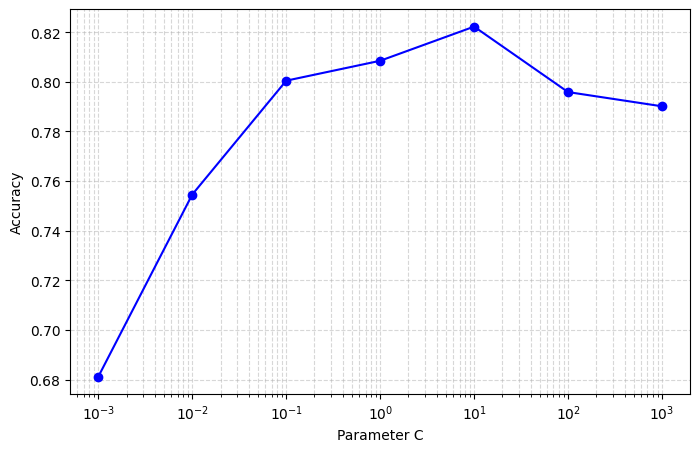

In [54]:
# 4. matplotlibを用いてグラフを描画
plt.figure(figsize=(8, 5))

# マーカー付きの折れ線グラフ
plt.plot(c_values, accuracies, marker='o', linestyle='-', color='b')

# 横軸（パラメータ C）は桁数が大きく変わるため、対数スケール(log)に設定
plt.xscale('log')

# ラベルを設定
plt.xlabel('Parameter C')
plt.ylabel('Accuracy')

# グリッド線を表示して見やすくする
plt.grid(True, which="both", ls="--", alpha=0.5)

# ウィンドウでグラフを表示
plt.show()